In [1]:
# --- 1.  pull the symmetry straight from the module -----------------
from orix.quaternion.symmetry import O, Oh   # cubic, w/ or w/o inversion

sym = Oh        # full m-3m symmetry for γ-Ni (Inconel 718 matrix)

# --- 2. or, derive it from the space-group number -------------------
from orix.quaternion.symmetry import get_point_group

sym     = get_point_group(225)          # → Oh  (m-3m)
sym_fcc = get_point_group(225, proper=True)   # → O   (432)

In [2]:
import orix, importlib, pathlib, sys
print("orix version:", orix.__version__)
print("loaded from :", pathlib.Path(orix.__file__))


orix version: 0.13.3
loaded from : /home/umang/miniconda3/envs/material/lib/python3.10/site-packages/orix/__init__.py


In [3]:
import inspect, orix
from orix.quaternion import Orientation
print(inspect.getfile(Orientation))


/home/umang/miniconda3/envs/material/lib/python3.10/site-packages/orix/quaternion/orientation.py


In [4]:
import numpy as np
from orix.quaternion import Orientation
from orix.quaternion.symmetry import get_point_group
from orix.vector import Vector3d
from orix.plot import IPFColorKeyTSL           # still available for legacy colour keys

sym_fcc = get_point_group(225, proper=True)    # cubic 432

def quaternion_to_ipf(quats, axis="Z"):
    ori = Orientation(np.asarray(quats), symmetry=sym_fcc)

    key = IPFColorKeyTSL(
        sym_fcc,
        direction=getattr(Vector3d, f"{axis.lower()}vector")()
    )
    return key.orientation2color(ori)          # (N, 3) in 0–1 RGB


In [5]:
Qs = [
    [1, 0, 0, 0],
    [0.92388, 0, 0.38268, 0],
    [0.70711, 0.70711, 0, 0],
]
print(quaternion_to_ipf(Qs, axis="Z"))

[[1.00000000e+00 1.11022302e-16 0.00000000e+00]
 [5.27049472e-03 1.00000000e+00 0.00000000e+00]
 [1.00000000e+00 1.11022302e-16 0.00000000e+00]]


[[1.00000000e+00 1.11022302e-16 0.00000000e+00]
 [4.91822244e-01 1.00000000e+00 2.84206240e-01]
 [1.40418575e-01 1.33115863e-01 1.00000000e+00]]


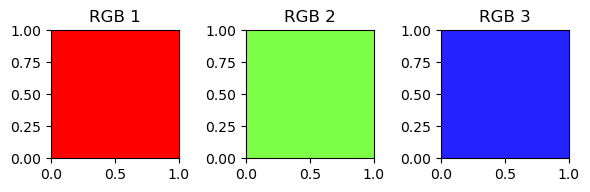

In [6]:
# get RGB colours for Qs
import os

#Example with three orientations
Qs = [
    [1, 0, 0, 0],      # identity
    [0.94177115, 0.07504171, -0.29972738, -0.13266438 ],     # supposed to be BLUE orientation
    [ 0.86994576, 0.3598948, 0.32445887, 0.09163266,]   # supposed to be GREEN orientation
]
rgbs = quaternion_to_ipf(Qs, axis="Z")  # ready for scatter
print(rgbs)  # prints RGB values in 0–1 range

# display RGB colours
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, len(rgbs), figsize=(len(rgbs)*2, 2))
for i, rgb in enumerate(rgbs):
    axes[i].add_patch(mpatches.Rectangle((0, 0), 1, 1, color=rgb))
    axes[i].set_xlim(0, 1)
    axes[i].set_ylim(0, 1)
    axes[i].set_title(f'RGB {i+1}')
    axes[i].set_aspect('equal')
plt.tight_layout()
plt.show()

### Blue fz reduced

In [7]:
# Median quaternions shape (fz_reduced): (10, 4)
# [-0.3543345   0.28639686 -0.17957486  0.8718811 ]
# [0.35879993 0.3283364  0.07821523 0.8702527 ]
# [0.36038938 0.32428646 0.07633916 0.87128043]
# [0.3601653  0.32436368 0.07681823 0.87130225]
# [-0.3579337  0.2793786 -0.1700078  0.8746015]
# [-0.35526988  0.28278702 -0.16215508  0.8760819 ]
# [0.35976163 0.32466963 0.07651326 0.87138236]
# [0.36000153 0.3245215  0.07670802 0.87132156]
# [-0.355242    0.28234264 -0.16284002  0.87611   ]
# [0.35427722 0.31952643 0.07654448 0.8755177 ]

[[ 0.8718811  -0.3543345   0.28639686 -0.17957486]
 [ 0.8702527   0.35879993  0.3283364   0.07821523]
 [ 0.87128043  0.36038938  0.32428646  0.07633916]
 [ 0.87130225  0.3601653   0.32436368  0.07681823]
 [ 0.8746015  -0.3579337   0.2793786  -0.1700078 ]
 [ 0.8760819  -0.35526988  0.28278702 -0.16215508]
 [ 0.87138236  0.35976163  0.32466963  0.07651326]
 [ 0.87132156  0.36000153  0.3245215   0.07670802]
 [ 0.87611    -0.355242    0.28234264 -0.16284002]
 [ 0.8755177   0.35427722  0.31952643  0.07654448]]
[[0.10868788 0.19267873 1.        ]
 [0.14110074 0.16287271 1.        ]
 [0.10793194 0.15143924 1.        ]
 [0.1109137  0.15111816 1.        ]
 [0.05905137 0.14402231 1.        ]
 [0.05995303 0.14500542 1.        ]
 [0.11297037 0.15081387 1.        ]
 [0.11196373 0.15113598 1.        ]
 [0.05780931 0.14561527 1.        ]
 [0.09758605 0.09949748 1.        ]]


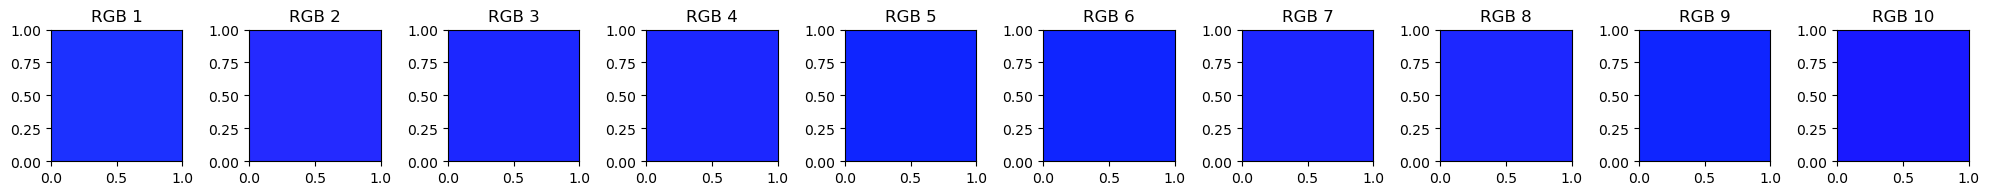

In [8]:
# get RGB colours for Qs
import os
# Example with ten orientations
Qs = [
    [-0.3543345,  0.28639686, -0.17957486,  0.8718811 ],
    [ 0.35879993, 0.3283364,   0.07821523,  0.8702527 ],
    [ 0.36038938, 0.32428646,  0.07633916,  0.87128043],
    [ 0.3601653,  0.32436368,  0.07681823,  0.87130225],
    [-0.3579337,  0.2793786,  -0.1700078,   0.8746015 ],
    [-0.35526988, 0.28278702, -0.16215508,  0.8760819 ],
    [ 0.35976163, 0.32466963,  0.07651326,  0.87138236],
    [ 0.36000153, 0.3245215,   0.07670802,  0.87132156],
    [-0.355242,   0.28234264, -0.16284002,  0.87611   ],
    [ 0.35427722, 0.31952643,  0.07654448,  0.8755177 ]
]

q = np.asarray(Qs)
# bring last quaternion dimension to the front (Scalar first)
# roll the last axis to the front (scalar first)
q = np.roll(q, shift=1, axis=-1)
print(q)  # prints quaternions in [s, x, y, z] order
rgbs = quaternion_to_ipf(q, axis="Z")  # ready for scatter
print(rgbs)  # prints RGB values in 0–1 range


# display RGB colours
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, len(rgbs), figsize=(len(rgbs)*2, 2))
for i, rgb in enumerate(rgbs):
    axes[i].add_patch(mpatches.Rectangle((0, 0), 1, 1, color=rgb))
    axes[i].set_xlim(0, 1)
    axes[i].set_ylim(0, 1)
    axes[i].set_title(f'RGB {i+1}')
    axes[i].set_aspect('equal')
plt.tight_layout()
plt.show()

### Blue fz not reduced.

In [79]:
# Median quaternions shape (not fz_reduced): (10, 4)
# Median Quaternion for blue Pixel 1 at (0, 0): [ 0.3656015   0.07226519 -0.32872546  0.86778605]
# Median Quaternion for blue Pixel 2 at (0, 1): [ 0.30917108 -0.38284126 -0.19843422  0.8476262 ]
# Median Quaternion for blue Pixel 3 at (0, 2): [ 0.3085266  -0.38642907 -0.20071746  0.8456929 ]
# Median Quaternion for blue Pixel 4 at (0, 3): [ 0.3084839  -0.38650846 -0.20086013  0.8456383 ]
# Median Quaternion for blue Pixel 5 at (0, 4): [ 0.36622816  0.07339534 -0.31672764  0.8718786 ]
# Median Quaternion for blue Pixel 6 at (0, 5): [ 0.36773974  0.08492741 -0.31411564  0.87114066]
# Median Quaternion for blue Pixel 7 at (0, 6): [ 0.30889922 -0.3866698  -0.20036927  0.8455294 ]
# Median Quaternion for blue Pixel 8 at (0, 7): [ 0.30818883 -0.38665807 -0.20101927  0.84563965]
# Median Quaternion for blue Pixel 9 at (0, 8): [ 0.36749256  0.08529094 -0.31339806  0.87146795]
# Median Quaternion for blue Pixel 10 at (0, 9): [ 0.30485877 -0.39321893 -0.19670784  0.8448349 ]

In [80]:
# get RGB colours for Qs
import os
#Example with three orientations
Qs = [
    [0.3656015,  0.07226519, -0.32872546,  0.86778605],
    [0.30917108, -0.38284126, -0.19843422,  0.8476262],
    [0.3085266,  -0.38642907, -0.20071746,  0.8456929],
    [0.3084839,  -0.38650846, -0.20086013,  0.8456383],
    [0.36622816,  0.07339534, -0.31672764,  0.8718786],
    [0.36773974,  0.08492741, -0.31411564,  0.87114066],
    [0.30889922, -0.3866698,  -0.20036927,  0.8455294],
    [0.30818883, -0.38665807, -0.20101927,  0.84563965],
    [0.36749256,  0.08529094, -0.31339806,  0.87146795],
    [0.30485877, -0.39321893, -0.19670784,  0.8448349]
]

q = np.asarray(Qs)
# bring last quaternion dimension to the front (Scalar first)
# roll the last axis to the front (scalar first)
q = np.roll(q, shift=1, axis=-1)

print(q)  # prints quaternions in [s, x, y, z] order
rgbs = quaternion_to_ipf(q, axis="Z")  # ready for scatter
print(rgbs)  # prints RGB values in 0–1 range


[[ 0.86778605  0.3656015   0.07226519 -0.32872546]
 [ 0.8476262   0.30917108 -0.38284126 -0.19843422]
 [ 0.8456929   0.3085266  -0.38642907 -0.20071746]
 [ 0.8456383   0.3084839  -0.38650846 -0.20086013]
 [ 0.8718786   0.36622816  0.07339534 -0.31672764]
 [ 0.87114066  0.36773974  0.08492741 -0.31411564]
 [ 0.8455294   0.30889922 -0.3866698  -0.20036927]
 [ 0.84563965  0.30818883 -0.38665807 -0.20101927]
 [ 0.87146795  0.36749256  0.08529094 -0.31339806]
 [ 0.8448349   0.30485877 -0.39321893 -0.19670784]]
[[0.10633248 1.         0.39795035]
 [0.59386042 0.53494293 1.        ]
 [0.60991814 0.53852119 1.        ]
 [0.6105896  0.53920009 1.        ]
 [0.09487154 1.         0.35687393]
 [0.0556198  1.         0.2747602 ]
 [0.60849207 0.53289507 1.        ]
 [0.61228657 0.54223248 1.        ]
 [0.05647166 1.         0.27038292]
 [0.62922109 0.54024521 1.        ]]


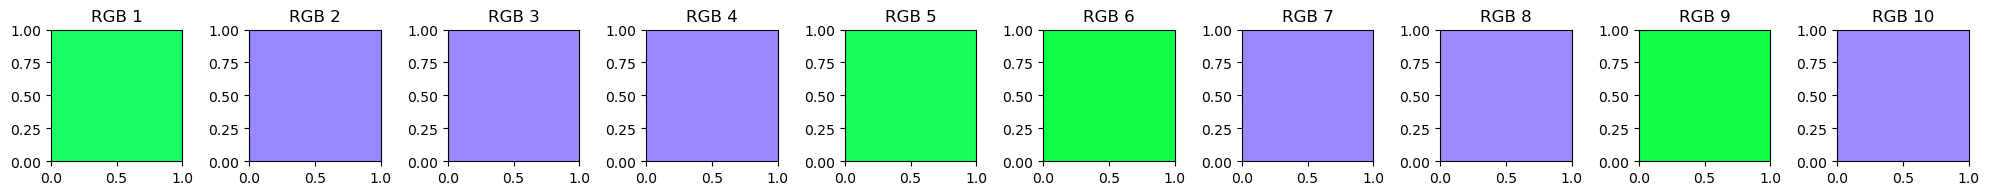

In [81]:
fig, axes = plt.subplots(1, len(rgbs), figsize=(len(rgbs)*2, 2))
for i, rgb in enumerate(rgbs):
    axes[i].add_patch(mpatches.Rectangle((0, 0), 1, 1, color=rgb))
    axes[i].set_xlim(0, 1)
    axes[i].set_ylim(0, 1)
    axes[i].set_title(f'RGB {i+1}')
    axes[i].set_aspect('equal')
plt.tight_layout()
plt.show()


### Green fz reduced.

In [82]:
# Median quaternions shape (not fz_reduced): (10, 4)
# Median Quaternion for green Pixel 1 at (0, 42): [ 0.8200964  -0.4135781   0.14032996  0.36973208]
# Median Quaternion for green Pixel 2 at (0, 121): [ 0.8200932  -0.4135676   0.14058788  0.36965466]
# Median Quaternion for green Pixel 3 at (1, 40): [ 0.87340623 -0.15551226 -0.29015696  0.35886902]
# Median Quaternion for green Pixel 4 at (1, 61): [ 0.8756516  -0.1618142  -0.28310966  0.3562304 ]
# Median Quaternion for green Pixel 5 at (1, 66): [ 0.874455   -0.16932276 -0.28549856  0.35376385]
# Median Quaternion for green Pixel 6 at (1, 71): [ 0.87562233 -0.16200612 -0.28348988  0.35591143]
# Median Quaternion for green Pixel 7 at (1, 72): [ 0.8209065  -0.41281882  0.13735732  0.36989874]
# Median Quaternion for green Pixel 8 at (1, 107): [ 0.81746817 -0.41513094  0.13799933  0.3746576 ]
# Median Quaternion for green Pixel 9 at (1, 109): [ 0.82068354 -0.41242373  0.14290011  0.36873308]
# Median Quaternion for green Pixel 10 at (1, 121): [ 0.82000905 -0.41364795  0.14172795  0.36931476]

# Median quaternions shape (fz_reduced): (10, 4)
# Median Quaternion for green Pixel 1 at (0, 42): [-0.36108774  0.16191638  0.28719065  0.8723076 ]
# Median Quaternion for green Pixel 2 at (0, 121): [0.3608814  0.31772375 0.08886707 0.87230664]
# Median Quaternion for green Pixel 3 at (1, 40): [-0.3591019   0.29029548 -0.15420505  0.8734962 ]
# Median Quaternion for green Pixel 4 at (1, 61): [-0.35499984  0.28363562 -0.16163787  0.876013  ]
# Median Quaternion for green Pixel 5 at (1, 66): [-0.35330218  0.2862902  -0.16726333  0.8747788 ]
# Median Quaternion for green Pixel 6 at (1, 71): [-0.3556354   0.2822507  -0.1622568   0.87608826]
# Median Quaternion for green Pixel 7 at (1, 72): [0.35984474 0.31792486 0.09071521 0.87247163]
# Median Quaternion for green Pixel 8 at (1, 107): [0.357193   0.3161878  0.08280744 0.87497544]
# Median Quaternion for green Pixel 9 at (1, 109): [0.36064187 0.3168099  0.09172913 0.87244165]
# Median Quaternion for green Pixel 10 at (1, 121): [-0.35952199  0.1630716   0.28784186  0.87252444]

In [83]:
Median quaternions shape (not fz_reduced): (10, 4)
Median Quaternion for green Pixel 1 at (0, 42): [-0.16212116 -0.36153328 -0.87205684  0.2872756 ]
Median Quaternion for green Pixel 2 at (0, 121): [ 0.6797613  -0.55372727 -0.47996837 -0.03067341]
Median Quaternion for green Pixel 3 at (1, 40): [ 0.50876707 -0.7262992   0.0484855   0.45966733]
Median Quaternion for green Pixel 4 at (1, 61): [ 0.4196091 -0.3656573 -0.8194158  0.1370406]
Median Quaternion for green Pixel 5 at (1, 66): [ 0.03361554 -0.5564783  -0.48818755  0.67147166]
Median Quaternion for green Pixel 6 at (1, 71): [ 0.41999754 -0.3667743  -0.81887674  0.13608252]
Median Quaternion for green Pixel 7 at (1, 72): [ 0.6842112  -0.5504913  -0.47758746 -0.02692364]
Median Quaternion for green Pixel 8 at (1, 107): [-0.16349256 -0.36732444 -0.87017465  0.2848505 ]
Median Quaternion for green Pixel 9 at (1, 109): [-0.16277166 -0.3612378  -0.87207425  0.28722653]
Median Quaternion for green Pixel 10 at (1, 121): [ 0.50340897 -0.05190995 -0.7297361   0.45975012]
Median quaternions shape (fz_reduced): (10, 4)
Median Quaternion for green Pixel 1 at (0, 42): [-0.36108774  0.16191638  0.28719065  0.8723076 ]
Median Quaternion for green Pixel 2 at (0, 121): [0.36104736 0.31742546 0.08926364 0.87230605]
Median Quaternion for green Pixel 3 at (1, 40): [-0.3588637   0.2909948  -0.15344663  0.8734947 ]
Median Quaternion for green Pixel 4 at (1, 61): [-0.35496968  0.28370562 -0.16162348  0.8760047 ]
Median Quaternion for green Pixel 5 at (1, 66): [-0.353507    0.2848725  -0.16930535  0.87476605]
Median Quaternion for green Pixel 6 at (1, 71): [-0.35518873  0.28290206 -0.16211669  0.8760854 ]
Median Quaternion for green Pixel 7 at (1, 72): [0.35984474 0.31792486 0.09071521 0.87247163]
Median Quaternion for green Pixel 8 at (1, 107): [0.357193   0.3161878  0.08280744 0.87497544]
Median Quaternion for green Pixel 9 at (1, 109): [0.36064187 0.3168099  0.09172913 0.87244165]
Median Quaternion for green Pixel 10 at (1, 121): [-0.3614022   0.16407657  0.28491923  0.87251806]

SyntaxError: invalid syntax (1701257657.py, line 1)

[[ 0.8723076  -0.36108774  0.16191638  0.28719065]
 [ 0.87230605  0.36104736  0.31742546  0.08926364]
 [ 0.8734947  -0.3588637   0.2909948  -0.15344663]
 [ 0.8760047  -0.35496968  0.28370562 -0.16162348]
 [ 0.87476605 -0.353507    0.2848725  -0.16930535]
 [ 0.8760854  -0.35518873  0.28290206 -0.16211669]
 [ 0.87247163  0.35984474  0.31792486  0.09071521]
 [ 0.87497544  0.357193    0.3161878   0.08280744]
 [ 0.87244165  0.36064187  0.3168099   0.09172913]
 [ 0.87251806 -0.3614022   0.16407657  0.28491923]]
[[0.09549015 1.         0.25956931]
 [0.11655004 0.13098488 1.        ]
 [0.11757594 0.13149097 1.        ]
 [0.06437786 0.14696386 1.        ]
 [0.07884656 0.17104884 1.        ]
 [0.0603786  0.14547623 1.        ]
 [0.1148248  0.11543788 1.        ]
 [0.10182556 0.1092113  1.        ]
 [0.1172108  0.12170231 1.        ]
 [0.10359695 1.         0.27939601]]


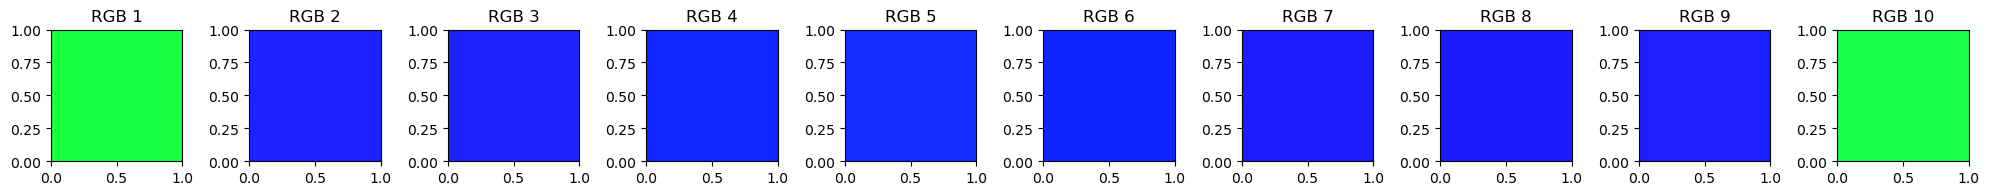

In [ ]:
# get RGB colours for Qs
import os
import numpy as np
#Example with three orientations
Qs = [
    [-0.36108774,  0.16191638,  0.28719065,  0.8723076 ],
    [ 0.36104736,  0.31742546,  0.08926364,  0.87230605],
    [-0.3588637,   0.2909948,  -0.15344663,  0.8734947 ],
    [-0.35496968,  0.28370562, -0.16162348,  0.8760047 ],
    [-0.353507,    0.2848725,  -0.16930535,  0.87476605],
    [-0.35518873,  0.28290206, -0.16211669,  0.8760854 ],
    [ 0.35984474,  0.31792486,  0.09071521,  0.87247163],
    [ 0.357193,    0.3161878,   0.08280744,  0.87497544],
    [ 0.36064187,  0.3168099,   0.09172913,  0.87244165],
    [-0.3614022,   0.16407657,  0.28491923,  0.87251806]
]
q = np.asarray(Qs)
# bring last quaternion dimension to the front (Scalar first)
# roll the last axis to the front (scalar first)
q = np.roll(q, shift=1, axis=-1)

print(q)  # prints quaternions in [s, x, y, z] order
rgbs = quaternion_to_ipf(q, axis="Z")  # ready for scatter
print(rgbs)  # prints RGB values in 0–1 range

# display RGB colours
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, len(rgbs), figsize=(len(rgbs)*2, 2))
for i, rgb in enumerate(rgbs):
    axes[i].add_patch(mpatches.Rectangle((0, 0), 1, 1, color=rgb))
    axes[i].set_xlim(0, 1)
    axes[i].set_ylim(0, 1)
    axes[i].set_title(f'RGB {i+1}')
    axes[i].set_aspect('equal')
plt.tight_layout()
plt.show()



### TEST WITH ORIGINAL SAMPLING FROM TORCH.

#### Blue fz reduced.

[[ 0.87164658 -0.35491991  0.28599367 -0.18019956]
 [ 0.87081176  0.35929981  0.32735288  0.07369888]
 [ 0.8710624   0.36061129  0.32475135  0.07580052]
 [ 0.87206542  0.36028659  0.3229546   0.07345694]
 [ 0.87456745 -0.35839033  0.27933127 -0.16930109]
 [ 0.8760125  -0.35585028  0.28216347 -0.16234644]
 [ 0.87116194  0.36038378  0.32446939  0.07694571]
 [ 0.87117976  0.36063606  0.3240574   0.07729717]
 [ 0.87612247 -0.35617211  0.28194529 -0.16142388]
 [ 0.87553388  0.35437757  0.31967306  0.07527435]]
[[0.10915624 0.19091895 1.        ]
 [0.11816339 0.15903969 1.        ]
 [0.10744591 0.15392694 1.        ]
 [0.09148229 0.14478155 1.        ]
 [0.0594217  0.14072301 1.        ]
 [0.05816246 0.14188298 1.        ]
 [0.11101964 0.15235905 1.        ]
 [0.10920508 0.15171907 1.        ]
 [0.05643952 0.13828376 1.        ]
 [0.10232638 0.10872404 1.        ]]


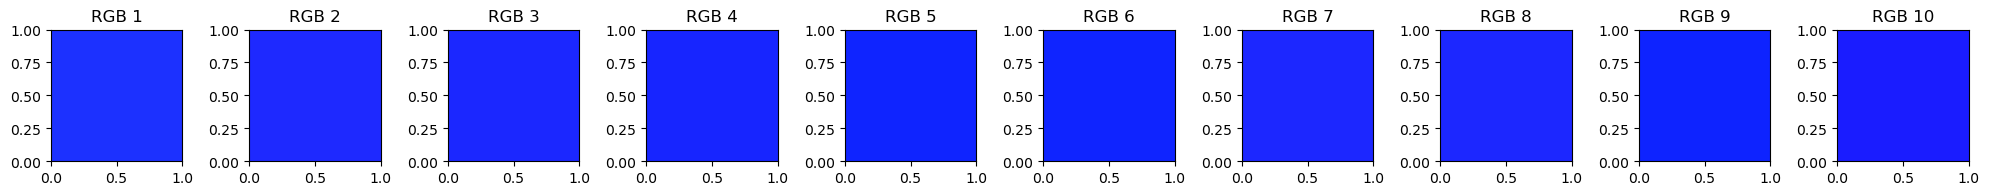

In [9]:
# get RGB colours for Qs
import os
import numpy as np
#Example with three orientations
Qs = [
    [-0.35491991,  0.28599367, -0.18019956,  0.87164658],
    [ 0.35929981,  0.32735288,  0.07369888,  0.87081176],
    [ 0.36061129,  0.32475135,  0.07580052,  0.8710624 ],
    [ 0.36028659,  0.3229546,   0.07345694,  0.87206542],
    [-0.35839033,  0.27933127, -0.16930109,  0.87456745],
    [-0.35585028,  0.28216347, -0.16234644,  0.8760125 ],
    [ 0.36038378,  0.32446939,  0.07694571,  0.87116194],
    [ 0.36063606,  0.3240574,   0.07729717,  0.87117976],
    [-0.35617211,  0.28194529, -0.16142388,  0.87612247],
    [ 0.35437757,  0.31967306,  0.07527435,  0.87553388]
]
    
q = np.asarray(Qs)
# bring last quaternion dimension to the front (Scalar first)
# roll the last axis to the front (scalar first)
q = np.roll(q, shift=1, axis=-1)

print(q)  # prints quaternions in [s, x, y, z] order
rgbs = quaternion_to_ipf(q, axis="Z")  # ready for scatter
print(rgbs)  # prints RGB values in 0–1 range

# display RGB colours
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, len(rgbs), figsize=(len(rgbs)*2, 2))
for i, rgb in enumerate(rgbs):
    axes[i].add_patch(mpatches.Rectangle((0, 0), 1, 1, color=rgb))
    axes[i].set_xlim(0, 1)
    axes[i].set_ylim(0, 1)
    axes[i].set_title(f'RGB {i+1}')
    axes[i].set_aspect('equal')
plt.tight_layout()
plt.show()



### Blue fz not reduced

[[ 0.12354594  0.41411915 -0.37838662 -0.81857526]
 [ 0.45628187  0.48822877 -0.0552301  -0.7418828 ]
 [-0.02535682  0.66953319 -0.56233507 -0.48462456]
 [ 0.45409518  0.49142718 -0.05768363 -0.74092484]
 [ 0.35839033  0.87456745 -0.16930109 -0.27933127]
 [ 0.13682787  0.41991466 -0.36642042 -0.81895411]
 [ 0.45609659  0.49201098 -0.05468149 -0.73953468]
 [ 0.37865195  0.81658518 -0.41523063  0.13189174]
 [ 0.87136388  0.36766043  0.08522149 -0.31350935]
 [ 0.45805186  0.49275637 -0.06310447 -0.73715508]]
[[0.59739134 0.54586527 1.        ]
 [0.61589613 0.57235509 1.        ]
 [0.10744581 0.15392689 1.        ]
 [0.62534157 0.55834934 1.        ]
 [0.0594217  0.14072301 1.        ]
 [0.60042322 0.3991157  1.        ]
 [0.60728676 0.5299977  1.        ]
 [0.13080542 1.         0.34967282]
 [0.05537733 1.         0.27117294]
 [0.63352218 0.55343917 1.        ]]


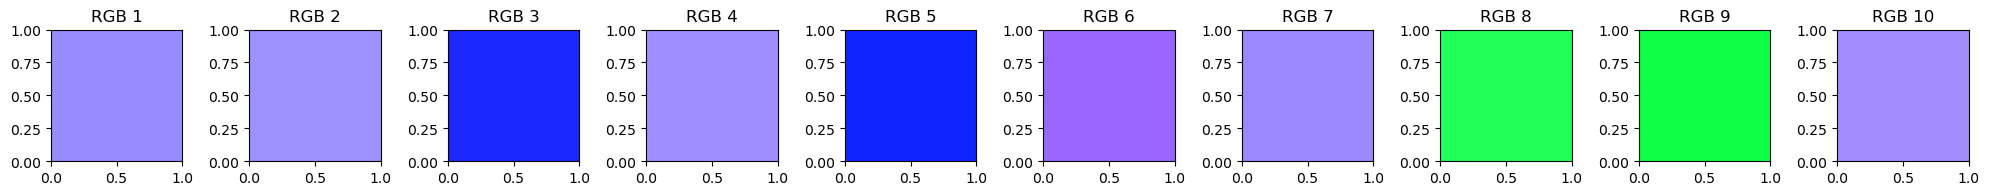

In [10]:
# get RGB colours for Qs
import os
#Example with three orientations
Qs = [
    [0.41411915, -0.37838662, -0.81857526, 0.12354594],
    [0.48822877, -0.0552301,  -0.7418828,  0.45628187],
    [0.66953319, -0.56233507, -0.48462456, -0.02535682],
    [0.49142718, -0.05768363, -0.74092484, 0.45409518],
    [0.87456745, -0.16930109, -0.27933127, 0.35839033],
    [0.41991466, -0.36642042, -0.81895411, 0.13682787],
    [0.49201098, -0.05468149, -0.73953468, 0.45609659],
    [0.81658518, -0.41523063,  0.13189174, 0.37865195],
    [0.36766043,  0.08522149, -0.31350935, 0.87136388],
    [0.49275637, -0.06310447, -0.73715508, 0.45805186]
]

q = np.asarray(Qs)
# bring last quaternion dimension to the front (Scalar first)
# roll the last axis to the front (scalar first)
q = np.roll(q, shift=1, axis=-1)

print(q)  # prints quaternions in [s, x, y, z] order
rgbs = quaternion_to_ipf(q, axis="Z")  # ready for scatter
print(rgbs)  # prints RGB values in 0–1 range

# display RGB colours
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, len(rgbs), figsize=(len(rgbs)*2, 2))
for i, rgb in enumerate(rgbs):
    axes[i].add_patch(mpatches.Rectangle((0, 0), 1, 1, color=rgb))
    axes[i].set_xlim(0, 1)
    axes[i].set_ylim(0, 1)
    axes[i].set_title(f'RGB {i+1}')
    axes[i].set_aspect('equal')
plt.tight_layout()
plt.show()



### Green fz reduced

[[ 0.87246054 -0.36029717  0.16237251  0.28745919]
 [ 0.8723433   0.3610214   0.31739119  0.08912142]
 [ 0.87332374 -0.35931829  0.29074946 -0.15381844]
 [ 0.87614375 -0.35532552  0.28189093 -0.16325945]
 [ 0.87470335 -0.35282633  0.28551501 -0.16996804]
 [ 0.87615764 -0.35509968  0.2816934  -0.16401586]
 [ 0.87688255  0.36308542  0.3090336   0.06119391]
 [ 0.87464219  0.35734054  0.31694371  0.08278975]
 [ 0.87258416  0.35922897  0.31832683  0.09065934]
 [ 0.87258554  0.35972512  0.31758815  0.09126799]]
[[0.09084258 1.         0.26185833]
 [0.11597831 0.13070354 1.        ]
 [0.11820093 0.13013536 1.        ]
 [0.05563449 0.14523217 1.        ]
 [0.08170821 0.17639811 1.        ]
 [0.05455527 0.14726958 1.        ]
 [0.03253034 0.10179185 1.        ]
 [0.10576226 0.11351026 1.        ]
 [0.11319666 0.10972865 1.        ]
 [0.11247584 0.11112426 1.        ]]


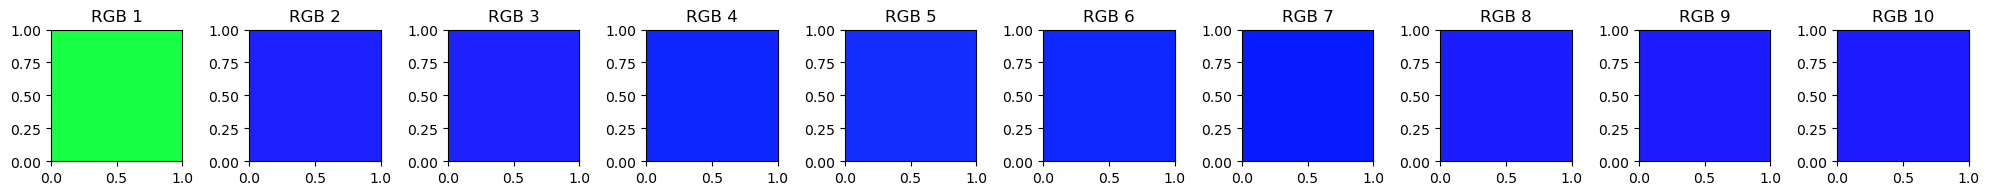

In [11]:
# get RGB colours for Qs
import os
#Example with three orientations
Qs = [
    [-0.36029717,  0.16237251,  0.28745919,  0.87246054],
    [ 0.3610214,   0.31739119,  0.08912142,  0.8723433 ],
    [-0.35931829,  0.29074946, -0.15381844,  0.87332374],
    [-0.35532552,  0.28189093, -0.16325945,  0.87614375],
    [-0.35282633,  0.28551501, -0.16996804,  0.87470335],
    [-0.35509968,  0.2816934,  -0.16401586,  0.87615764],
    [ 0.36308542,  0.3090336,   0.06119391,  0.87688255],
    [ 0.35734054,  0.31694371,  0.08278975,  0.87464219],
    [ 0.35922897,  0.31832683,  0.09065934,  0.87258416],
    [ 0.35972512,  0.31758815,  0.09126799,  0.87258554]
]
q = np.asarray(Qs)
# bring last quaternion dimension to the front (Scalar first)
# roll the last axis to the front (scalar first)
q = np.roll(q, shift=1, axis=-1)

print(q)  # prints quaternions in [s, x, y, z] order
rgbs = quaternion_to_ipf(q, axis="Z")  # ready for scatter
print(rgbs)  # prints RGB values in 0–1 range

# display RGB colours
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, len(rgbs), figsize=(len(rgbs)*2, 2))
for i, rgb in enumerate(rgbs):
    axes[i].add_patch(mpatches.Rectangle((0, 0), 1, 1, color=rgb))
    axes[i].set_xlim(0, 1)
    axes[i].set_ylim(0, 1)
    axes[i].set_title(f'RGB {i+1}')
    axes[i].set_aspect('equal')
plt.tight_layout()
plt.show()

### Green fz not reduced

[[ 0.31807905  0.08844963 -0.87169135 -0.36215419]
 [ 0.31739119  0.08912142 -0.8723433  -0.3610214 ]
 [ 0.45966733  0.50876707 -0.72629923  0.0484855 ]
 [ 0.67505038  0.0378339  -0.5564189  -0.48298433]
 [ 0.67153829  0.03319696 -0.55599135 -0.48868001]
 [ 0.45028073  0.5035603  -0.73551375  0.05190608]
 [ 0.38081843  0.80509776 -0.43487024  0.13297874]
 [ 0.31694371  0.08278975 -0.87464219 -0.35734054]
 [-0.02892218  0.68111604 -0.55290437 -0.47910431]
 [-0.02979534  0.6815474  -0.55247498 -0.47893283]]
[[0.11265605 0.13713454 1.        ]
 [0.11597831 0.13070354 1.        ]
 [0.11820096 0.13013535 1.        ]
 [0.60131997 0.40669353 1.        ]
 [0.5849596  0.44624492 1.        ]
 [0.05455534 0.14726955 1.        ]
 [0.14357181 1.         0.41522613]
 [0.10576226 0.11351026 1.        ]
 [0.1131966  0.10972856 1.        ]
 [0.11247582 0.11112426 1.        ]]


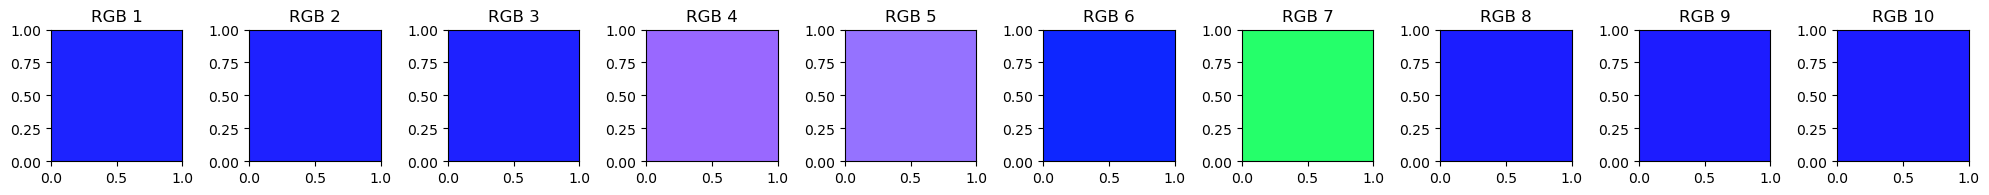

In [196]:
# get RGB colours for Qs
import os
#Example with three orientations
Qs = [
    [ 0.08844963, -0.87169135, -0.36215419,  0.31807905],
    [ 0.08912142, -0.8723433,  -0.3610214,   0.31739119],
    [ 0.50876707, -0.72629923,  0.0484855,   0.45966733],
    [ 0.0378339,  -0.5564189,  -0.48298433,  0.67505038],
    [ 0.03319696, -0.55599135, -0.48868001,  0.67153829],
    [ 0.5035603,  -0.73551375,  0.05190608,  0.45028073],
    [ 0.80509776, -0.43487024,  0.13297874,  0.38081843],
    [ 0.08278975, -0.87464219, -0.35734054,  0.31694371],
    [ 0.68111604, -0.55290437, -0.47910431, -0.02892218],
    [ 0.6815474,  -0.55247498, -0.47893283, -0.02979534]
]
q = np.asarray(Qs)
# bring last quaternion dimension to the front (Scalar first)
# roll the last axis to the front (scalar first)
q = np.roll(q, shift=1, axis=-1)

print(q)  # prints quaternions in [s, x, y, z] order
rgbs = quaternion_to_ipf(q, axis="Z")  # ready for scatter
print(rgbs)  # prints RGB values in 0–1 range

# display RGB colours
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, len(rgbs), figsize=(len(rgbs)*2, 2))
for i, rgb in enumerate(rgbs):
    axes[i].add_patch(mpatches.Rectangle((0, 0), 1, 1, color=rgb))
    axes[i].set_xlim(0, 1)
    axes[i].set_ylim(0, 1)
    axes[i].set_title(f'RGB {i+1}')
    axes[i].set_aspect('equal')
plt.tight_layout()
plt.show()



In [182]:
import numpy as np
# load npy file 
notfz_npy_path="/home/umang/a100_mount/Materials/QRBSA-data-augmentation/Quaternion_experiments/transposeConv_multipass_outerprod_kernel_3,4_extra_conv/sr_save/sr_not_fz_reduced_qrbsa_1d_model_best_minimum_angle_transformation.npy"
#notfz_npy_path= "/home/umang/a100_mount/Materials/QRBSA-data-augmentation/Quaternion_experiments/transposeConv_multipass_outerprod_kernel_3,4_extra_conv/sr_save/sr_save_qrbsa_1d_model_best_minimum_angle_transformation.npy"
not_fz_data = np.load(notfz_npy_path)

In [183]:
# load original median indices
median_indices_path = "/home/umang/a100_mount/Materials/QRBSA-data-augmentation/Quaternion_experiments/transposeConv_multipass_outerprod_kernel_3,4_extra_conv/sr_save/sr_median_indices_qrbsa_1d_model_best_minimum_angle_transformation.npy"
median_indices = np.load(median_indices_path)

In [184]:
# send 1st dim to last for median indices
median_indices = np.moveaxis(median_indices, 1, -1)
median_indices.shape

(1, 304, 390, 4)

In [185]:
not_fz_data = not_fz_data[:, :301, :390, :]
median_indices = median_indices[:, :301, :390, :]
median_indices.shape, not_fz_data.shape

((1, 301, 390, 4), (100, 301, 390, 4))

In [186]:
# pool median quaternions from data using median indices
# median indices shape (1, 301, 390, 4), data shape  (100, 301, 390, 4)

notfz_pooled_data = np.zeros((1, median_indices.shape[1], median_indices.shape[2], not_fz_data.shape[-1]))
for i in range(median_indices.shape[1]):
    for j in range(median_indices.shape[2]):
        notfz_pooled_data[0, i, j, :] = not_fz_data[median_indices[0,i,j,0], i,j,:]
notfz_pooled_data.shape

(1, 301, 390, 4)

In [187]:
notfz_pooled_data_sampled = notfz_pooled_data[:, 140:220, 90:220, :]
print(notfz_pooled_data_sampled[:, 0, 0:10, :])

[[[ 0.41411915 -0.37838662 -0.81857526  0.12354594]
  [ 0.48822877 -0.0552301  -0.7418828   0.45628187]
  [ 0.66953319 -0.56233507 -0.48462456 -0.02535682]
  [ 0.49142718 -0.05768363 -0.74092484  0.45409518]
  [ 0.87456745 -0.16930109 -0.27933127  0.35839033]
  [ 0.41991466 -0.36642042 -0.81895411  0.13682787]
  [ 0.49201098 -0.05468149 -0.73953468  0.45609659]
  [ 0.81658518 -0.41523063  0.13189174  0.37865195]
  [ 0.36766043  0.08522149 -0.31350935  0.87136388]
  [ 0.49275637 -0.06310447 -0.73715508  0.45805186]]]


In [188]:
# get RGB colours for Qs
import os
#Example with three orientations
Qs = notfz_pooled_data  # Convert numpy array to list
# bring last quaternion dimension to the front (Scalar first)
# reshape Qs to (-1, 4) if needed
q = np.asarray(Qs).reshape(-1, 4)  # Flatten if necessary

# roll the last axis to the front (scalar first)
q = np.roll(q, shift=1, axis=-1)

print(q)  # prints quaternions in [s, x, y, z] order
rgbs = quaternion_to_ipf(q, axis="Z")  # ready for scatter
print(rgbs)  # prints RGB values in 0–1 range

[[-0.02944313 -0.16463278 -0.79927623  0.57722229]
 [ 0.596416    0.03897642 -0.78299785 -0.17228544]
 [ 0.38826168  0.44700652 -0.68056166  0.43159327]
 ...
 [ 0.46229428  0.18164386 -0.38275743 -0.77896494]
 [-0.21600941  0.40196636 -0.13859195 -0.87895089]
 [-0.05651183  0.90590829 -0.25039339 -0.33680835]]
[[1.         0.6672936  0.6473722 ]
 [1.         0.02212931 0.51392589]
 [1.         0.65711194 0.64472744]
 ...
 [0.01084791 0.45875712 1.        ]
 [0.02188724 0.49447765 1.        ]
 [0.49086345 0.92206944 1.        ]]


In [189]:
[[ 0.41411915 -0.37838662 -0.81857526  0.12354594]
 [ 0.48822877 -0.0552301  -0.7418828   0.45628187]
 [ 0.66953319 -0.56233507 -0.48462456 -0.02535682]
 [ 0.49142718 -0.05768363 -0.74092484  0.45409518]
 [ 0.87456745 -0.16930109 -0.27933127  0.35839033]
 [ 0.41991466 -0.36642042 -0.81895411  0.13682787]
 [ 0.49201098 -0.05468149 -0.73953468  0.45609659]
 [ 0.81658518 -0.41523063  0.13189174  0.37865195]
 [ 0.36766043  0.08522149 -0.31350935  0.87136388]
 [ 0.49275637 -0.06310447 -0.73715508  0.45805186]]
[[0.38341484 1.         0.46372802]
 [0.40109404 1.         0.45593261]
 [0.41523223 1.         0.44601102]
 [0.43445789 1.         0.46002331]
 [0.45819616 1.         0.43902254]
 [0.4390255  1.         0.38308379]
 [0.41422262 1.         0.43843929]
 [0.41640762 1.         0.43691097]
 [0.43922035 1.         0.37580134]
 [0.44731267 1.         0.43357504]]

SyntaxError: invalid syntax. Perhaps you forgot a comma? (2769690744.py, line 1)

In [190]:
print(rgbs)


[[1.         0.6672936  0.6473722 ]
 [1.         0.02212931 0.51392589]
 [1.         0.65711194 0.64472744]
 ...
 [0.01084791 0.45875712 1.        ]
 [0.02188724 0.49447765 1.        ]
 [0.49086345 0.92206944 1.        ]]


In [191]:
print("Shape of rgbs:", rgbs.shape)  # Check the shape of the RGB array

#reshape rgbs to match the original data shape
rgbs_reshaped = rgbs.reshape(1, median_indices.shape[1], median_indices.shape[2], 3)
print("Shape of reshaped rgbs:", rgbs_reshaped.shape)  # Should match (1, 301, 390, 3)

Shape of rgbs: (117390, 3)
Shape of reshaped rgbs: (1, 301, 390, 3)


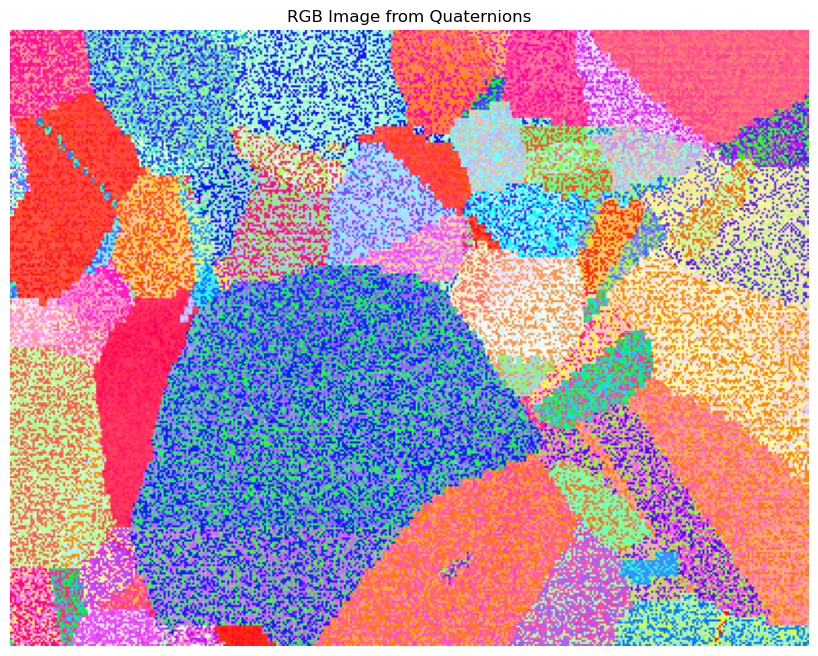

In [192]:
# plot rgbs_reshaped as an image
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.imshow(rgbs_reshaped[0])
plt.axis('off')
plt.title('RGB Image from Quaternions')
plt.show()

In [193]:
rgbs_Sampled[0, 0:10, :]  # Display the first 10 pixels of the sampled RGB image

IndexError: index 0 is out of bounds for axis 0 with size 0

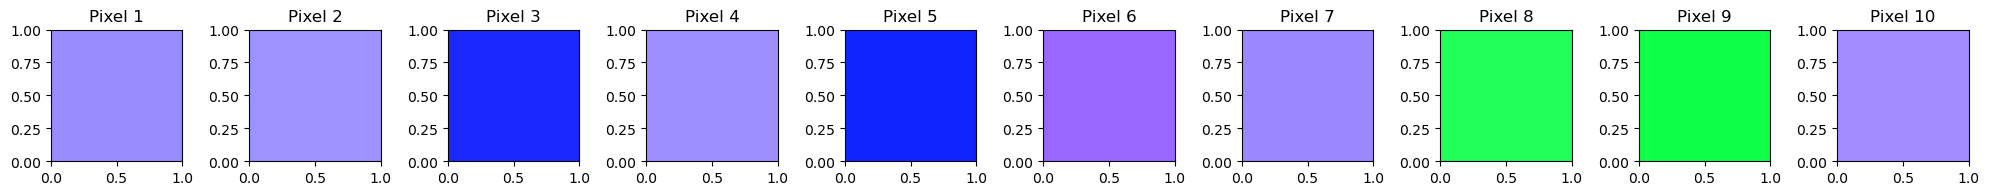

In [ ]:
# display first 10 pixels of rgbs_Sampled
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
fig, axes = plt.subplots(1, 10, figsize=(20, 2))
for i in range(10):
    rgb = rgbs_Sampled[0, i, :]
    axes[i].add_patch(mpatches.Rectangle((0, 0), 1, 1, color=rgb))
    axes[i].set_xlim(0, 1)
    axes[i].set_ylim(0, 1)
    axes[i].set_title(f'Pixel {i+1}')
    axes[i].set_aspect('equal')
plt.tight_layout()
plt.show()